# Streaming

In module 2, covered a few ways to customize graph state and memory.

This module will dive into `human-in-the-loop`, which builds on memory and allows users to interact directly with graphs in various ways.

To set the stage for `human-in-the-loop`, we'll first dive into streaming, which provides several ways to visualize graph output (e.g. node state or chat model tokens) over the course of execution.


In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}:")

_set_env("ANTHROPIC_API_KEY")

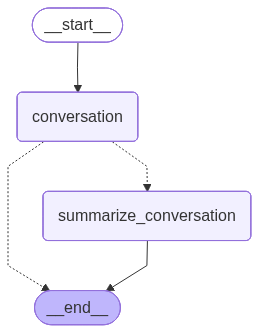

In [2]:
from IPython.display import Image, display
from typing import Literal

from langchain_anthropic import ChatAnthropic
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

# LLM
model = ChatAnthropic(model="claude-haiku-4-5", temperature=0)

# State
class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State, config: RunnableConfig):
    # Get summary if it exists
    summary = state.get("summary", "")
    
    # If there is summary, then we add it
    if summary:
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]

    else:
        messages = state['messages']
    
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt
    if summary:
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)   

    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State) -> Literal ["summarize_conversation", END]:
    """Return the next node to execute."""

    messages = state["messages"]

    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # otherwise we can just end
    return END



# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)


# compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

## Streaming full state

Now, let's talk about ways to stream our graph state.

`.stream` and `.astream` are sync and async methods for streaming back results.

LangGraph supports a few different streaming modes for graph state.

- `values` - This streams the full state of the graph after each node is called.
- `updates` - This streams updates to the state of the graph after each node is called.

Let's see the `stream_mode="updates"`

In [4]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="Hi! I'm Saket")]}, config,stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content='Hi Saket! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'id': 'msg_011CcqsVoq4eRd19rvLVX7kf', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 14, 'output_tokens': 20, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019f452f-7125-7372-b7c5-b4eb51ebd6b6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 20, 'total_tokens': 34, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}})}}


In [5]:
# Start a conversation
for chunk in graph.stream({"messages": [HumanMessage(content="Hi! I'm Saket")]}, config, stream_mode="updates"):
    chunk["conversation"]["messages"].pretty_print()

================================== Ai Message ==================================

Hi Saket! Nice to meet you. 👋 How's it going? Is there something I can help you with?


Now let's see the `stream_mode="values"`

In [6]:
config = {"configurable": {"thread_id": "2"}}

# Start Conversation
input_message = HumanMessage(content="Hi! I'm Saket")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event["messages"]:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

Hi! I'm Saket
---------------------------------------------------------------------------
================================ Human Message =================================

Hi! I'm Saket
================================== Ai Message ==================================

Hi Saket! Nice to meet you. How can I help you today?
---------------------------------------------------------------------------


## Streaming Tokens

We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the tokens as they are generated.

We can do this using the `.astream_events` method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:
- `event`: This is the type of event that is being emitted
- `name`: This is the name of the event
- `data`: This is the data associated with the event
- `metadata`: Contains `langgraph_node`, the node emitting the event.

Let's have a look.

In [7]:
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="Tell me about the Manchester United Team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event['metadata'].get('langgraph_node', '')}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conversation. Type: on_chat_model_stream. Name: ChatAnthropic
Node: conv

In [8]:
node_to_stream = "conversation"
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Tell me about Manchester United Team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node', '') == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019f4545-68c3-7143-bf86-9e9e23a92998', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='#', additional_kwargs={}, response_metadata={'model_provider': 'anthropic'}, id='lc_run--019f4545-68c3-7143-bf86-9e9e23a92998', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=" Manchester United\n\n## Overview\nManchester United is one of the world's most famous football clubs, based in Manchester, England. They compete", additional_kwargs={}, response_metadata={'model_provider': 'anthropic'}, id='lc_run--019f4545-68c3-7143-bf86-9e9e23a92998', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' in the **Premier League**, the top tier of English football.\n\n## Key Facts\n\n**History &', additional_kwargs={

In [9]:
config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="Tell me about Manchester United Team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    if event["event"] == "on_chat_model_stream" and event['metadata'].get("langgraph_node", '') == node_to_stream:
        data = event["data"]
        print(data['chunk'].content, end="|")

|#| Manchester United

## Overview
Manchester United is one of the world's most famous football clubs, based in Manchester, England. They compete| in the **Premier League**, the top tier of English football.

## Key Facts

**History &| Success**
- Founded in 1878 (originally as Newton Heath)
- One of England|'s most successful clubs with numerous trophies
- Won the historic **"|Treble"** in 1999 (Premier League, FA Cup, Champions League)
- 13-|time Premier League champions

**Notable Eras**
- **Sir Matt Busby era**| (1945-1969): Built the club into a powerhouse
- **Sir Alex Ferguson era** (1986-2013): Unprecedented| dominance with 49 major trophies
- **Modern era**: Various managers including| Ole Gunnar Solskjaer, Erik ten Hag

**Stadium**
- **Old Trafford** - iconic| 74,000+ capacity stadium, known as "The Theatre| of Dreams"

**Current Status**
- Under manager **Erik ten Hag** (since 2022)
-| Competing for Premier League and European titles
- Notable recent| players include Bruno Fe

## Streaming with LangGraph API

In [12]:
from langgraph_sdk import get_client

# This is the URL of the local development server
URL = "http://127.0.0.1:2024"
client = get_client(url=URL)

# Search all hosted graphs
assistants = await client.assistants.search()

Let's stream `values`, like before.

In [13]:
# Create a new thread
thread = await client.threads.create()
# Input message
input_message = HumanMessage(content="Multiply 2 and 3")
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent",  
                                      input={"messages": [input_message]},
                                      stream_mode="values"):
    print(event)

StreamPart(event='metadata', data={'run_id': '019f4563-0407-7853-8422-5ec55f9c5565', 'attempt': 1}, id=None)
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '1976b156-78b0-47fa-be2c-a86aded80379'}]}, id=None)
StreamPart(event='error', data={'error': 'TypeError', 'message': '"Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"'}, id=None)
